# Notebook 8: Model Monitoring and Drift Detection
## Goal
In production a fraud model degrades over time as fraud patterns change. Fraudsters adapt. This notebook simulates what happens when the data distribution shifts and shows how to detect it before model performance drops.

This directly answers the interview question: how would you monitor a fraud model in production?

Three things to monitor:
- Data drift: input feature distributions changing over time
- Prediction drift: model output distribution changing
- Performance drift: actual PR-AUC dropping on new labelled data

## Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from scipy import stats
from sklearn.metrics import average_precision_score

MODELS_PATH  = Path('../outputs/models')
FIGURES_PATH = Path('../outputs/figures')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

model     = joblib.load(MODELS_PATH / 'best_xgb.pkl')
THRESHOLD = 0.28
FEATURES  = [f'V{i}' for i in range(1, 29)] + ['log_amount', 'hour_of_day']

print('Model loaded :', type(model).__name__)
print('Features     :', len(FEATURES))
print('Threshold    :', THRESHOLD)

Model loaded : XGBClassifier
Features     : 30
Threshold    : 0.28


## 1. Load Data and Create Reference / Production Windows

We treat the first 80 % of transactions (sorted by `Time`) as the **reference** window — the distribution the model was trained on. The remaining 20 % become the **production** window.

In a real system these would be separate date-partitioned tables in your data warehouse.

In [5]:
df = pd.read_csv('../data/raw/creditcard.csv')

df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] % 86400) / 3600

X = df[FEATURES]
y = df['Class']

split   = int(len(df) * 0.8)
X_ref,  y_ref  = X.iloc[:split],  y.iloc[:split]
X_prod, y_prod = X.iloc[split:],  y.iloc[split:]

print(f'Reference  : {len(X_ref):>7,} rows | fraud rate: {y_ref.mean():.4%}')
print(f'Production : {len(X_prod):>7,} rows | fraud rate: {y_prod.mean():.4%}')

Reference  : 227,845 rows | fraud rate: 0.1830%
Production :  56,962 rows | fraud rate: 0.1317%


## 2. Simulate Concept Drift in the Production Window

We inject drift into the production window by shifting the three most important features (V14, V4, V12 — top SHAP features from notebook 05) and scaling up transaction amounts. This mimics fraudsters changing behaviour over time.

In [7]:
rng = np.random.default_rng(42)

X_prod_drifted = X_prod.copy()

X_prod_drifted['V14'] = X_prod_drifted['V14'] + rng.normal(0.8,  0.3, len(X_prod))
X_prod_drifted['V4']  = X_prod_drifted['V4']  + rng.normal(0.5,  0.2, len(X_prod))
X_prod_drifted['V12'] = X_prod_drifted['V12'] + rng.normal(-0.6, 0.3, len(X_prod))
X_prod_drifted['log_amount'] = X_prod_drifted['log_amount'] * 1.2

print('Drift injected into V14, V4, V12, log_amount')

Drift injected into V14, V4, V12, log_amount


## 3. Data Drift — Kolmogorov-Smirnov Test

The KS test compares two distributions without assuming normality. A low p-value (< 0.05) means the two samples are unlikely to come from the same distribution. We run it on every input feature and flag those that drift.

In [9]:
ks_rows = []
for col in FEATURES:
    stat, p = stats.ks_2samp(X_ref[col], X_prod_drifted[col])
    ks_rows.append({'feature': col, 'ks_stat': round(stat, 4), 'p_value': round(p, 6)})

ks_df = pd.DataFrame(ks_rows).sort_values('ks_stat', ascending=False)
ks_df['drifted'] = ks_df['p_value'] < 0.05

print(f"Features flagged as drifted: {ks_df['drifted'].sum()} / {len(FEATURES)}")
ks_df.head(10)

Features flagged as drifted: 30 / 30


,feature,ks_stat,p_value,drifted
29,hour_of_day,0.7211,0.0,True
13,V14,0.3651,0.0,True
2,V3,0.3471,0.0,True
11,V12,0.2728,0.0,True
0,V1,0.2652,0.0,True
27,V28,0.2230,0.0,True
24,V25,0.2188,0.0,True
14,V15,0.1662,0.0,True
4,V5,0.1581,0.0,True
10,V11,0.1429,0.0,True


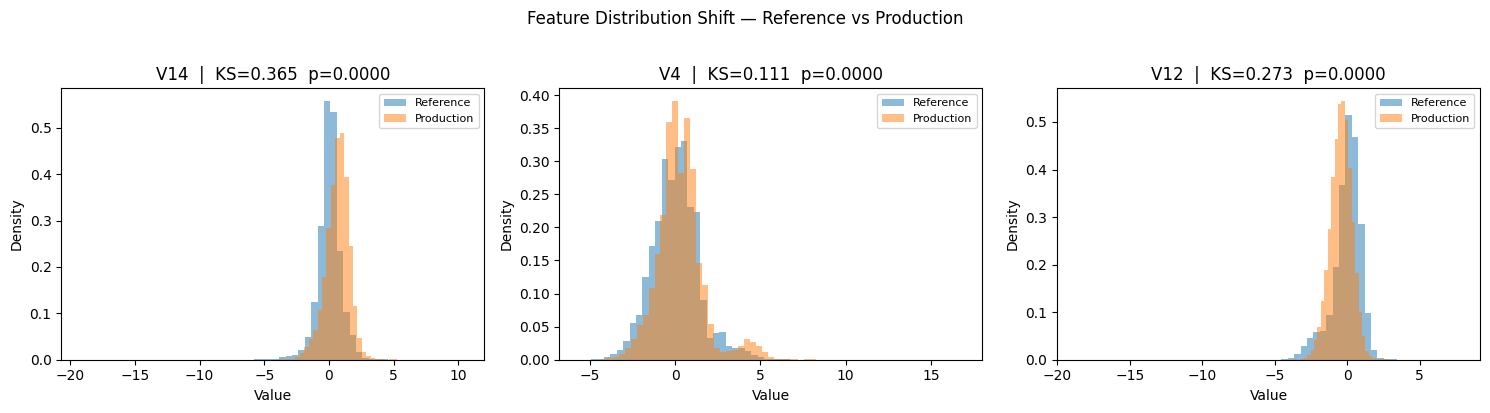

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, ['V14', 'V4', 'V12']):
    ax.hist(X_ref[feat],          bins=60, alpha=0.5, label='Reference',  density=True)
    ax.hist(X_prod_drifted[feat], bins=60, alpha=0.5, label='Production', density=True)
    row = ks_df[ks_df['feature'] == feat].iloc[0]
    ax.set_title(f'{feat}  |  KS={row.ks_stat:.3f}  p={row.p_value:.4f}')
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

plt.suptitle('Feature Distribution Shift — Reference vs Production', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '08_data_drift_ks.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Drift — Population Stability Index (PSI)

PSI is the standard drift metric used by fraud and risk teams in financial services. It measures how much a feature's distribution has shifted relative to a baseline.

| PSI | Interpretation |
|-----|----------------|
| < 0.10 | No significant change |
| 0.10 – 0.20 | Moderate change — investigate |
| > 0.20 | Significant change — schedule retrain |

In [12]:
def psi(reference: np.ndarray, production: np.ndarray, buckets: int = 10) -> float:
    breakpoints  = np.unique(np.percentile(reference, np.linspace(0, 100, buckets + 1)))
    ref_counts   = np.histogram(reference,  bins=breakpoints)[0] + 1e-6
    prod_counts  = np.histogram(production, bins=breakpoints)[0] + 1e-6
    ref_pct  = ref_counts  / ref_counts.sum()
    prod_pct = prod_counts / prod_counts.sum()
    return float(np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct)))


psi_rows = []
for col in FEATURES:
    score = psi(X_ref[col].values, X_prod_drifted[col].values)
    psi_rows.append({'feature': col, 'psi': round(score, 4)})

psi_df = pd.DataFrame(psi_rows).sort_values('psi', ascending=False)
psi_df['alert'] = pd.cut(
    psi_df['psi'],
    bins=[-np.inf, 0.10, 0.20, np.inf],
    labels=['OK', 'Investigate', 'Retrain'],
)
print(psi_df.head(10).to_string(index=False))

    feature     psi       alert
hour_of_day 16.5695     Retrain
         V1  0.8236     Retrain
        V14  0.6701     Retrain
         V3  0.5718     Retrain
        V12  0.4737     Retrain
        V28  0.4003     Retrain
        V11  0.2669     Retrain
        V25  0.2183     Retrain
        V15  0.1658 Investigate
 log_amount  0.1523 Investigate


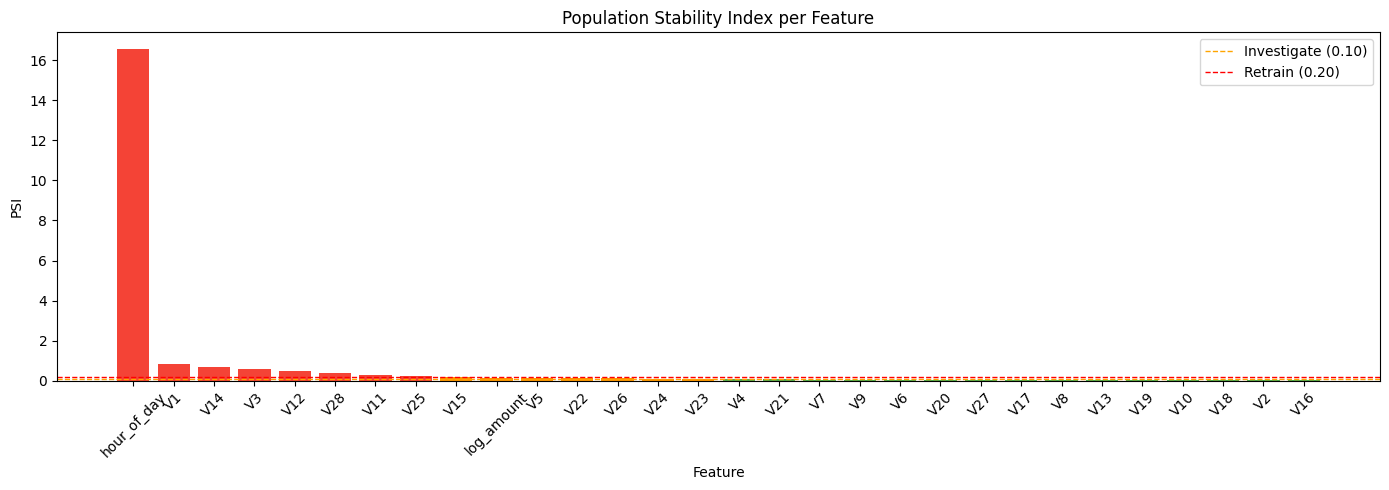

In [13]:
colours = {'OK': '#4caf50', 'Investigate': '#ff9800', 'Retrain': '#f44336'}

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(psi_df['feature'], psi_df['psi'],
       color=[colours[str(a)] for a in psi_df['alert']])
ax.axhline(0.10, color='orange', linestyle='--', linewidth=1, label='Investigate (0.10)')
ax.axhline(0.20, color='red',    linestyle='--', linewidth=1, label='Retrain (0.20)')
ax.set_xlabel('Feature')
ax.set_ylabel('PSI')
ax.set_title('Population Stability Index per Feature')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / '08_psi_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Prediction Drift

Even if individual features look stable, the model's *output distribution* can shift. Comparing score distributions is a label-free early-warning signal — it fires before you have enough labelled production data to measure PR-AUC.

Prediction KS stat : 0.1013
Prediction KS p    : 0.00e+00
Score distribution drifted: True


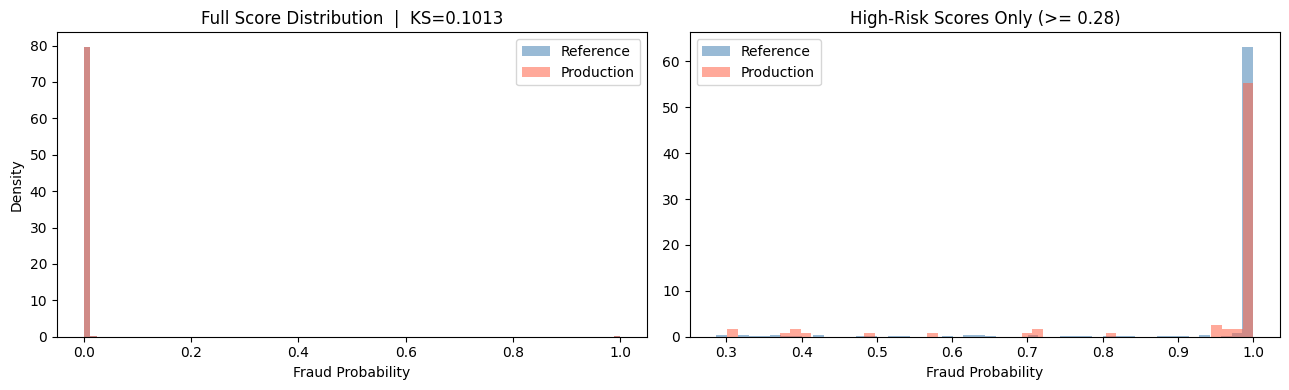

In [15]:
probs_ref  = model.predict_proba(X_ref)[:, 1]
probs_prod = model.predict_proba(X_prod_drifted)[:, 1]

ks_stat, ks_p = stats.ks_2samp(probs_ref, probs_prod)
print(f'Prediction KS stat : {ks_stat:.4f}')
print(f'Prediction KS p    : {ks_p:.2e}')
print(f'Score distribution drifted: {ks_p < 0.05}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(probs_ref,  bins=80, alpha=0.55, label='Reference',  density=True, color='steelblue')
axes[0].hist(probs_prod, bins=80, alpha=0.55, label='Production', density=True, color='tomato')
axes[0].set_xlabel('Fraud Probability')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Full Score Distribution  |  KS={ks_stat:.4f}')
axes[0].legend()

axes[1].hist(probs_ref[probs_ref   >= THRESHOLD], bins=50, alpha=0.55,
             label='Reference',  density=True, color='steelblue')
axes[1].hist(probs_prod[probs_prod >= THRESHOLD], bins=50, alpha=0.55,
             label='Production', density=True, color='tomato')
axes[1].set_xlabel('Fraud Probability')
axes[1].set_title(f'High-Risk Scores Only (>= {THRESHOLD})')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / '08_prediction_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Performance Drift — PR-AUC Over Time

The most reliable signal, but the slowest to arrive: you need ground-truth labels. We split the production window into 5 equal time buckets and compute PR-AUC for each. A declining trend means the model is actively degrading and retraining is overdue.

 bucket  pr_auc  n_fraud
      1  1.0000       18
      2  0.9594       23
      3  1.0000       16
      4  1.0000        8
      5  0.9809       10


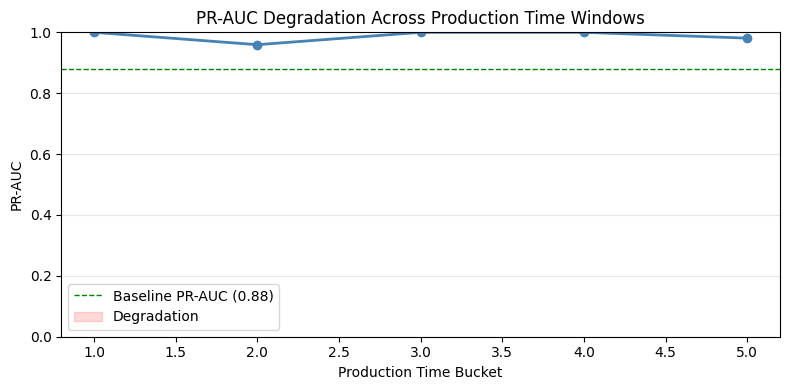

In [17]:
N_BUCKETS   = 5
bucket_size = len(X_prod) // N_BUCKETS

perf_rows = []
for i in range(N_BUCKETS):
    start, end = i * bucket_size, (i + 1) * bucket_size
    X_b, y_b   = X_prod_drifted.iloc[start:end], y_prod.iloc[start:end]
    if y_b.sum() == 0:
        continue
    pr_auc = average_precision_score(y_b, model.predict_proba(X_b)[:, 1])
    perf_rows.append({'bucket': i + 1, 'pr_auc': round(pr_auc, 4), 'n_fraud': int(y_b.sum())})

perf_df = pd.DataFrame(perf_rows)
print(perf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(perf_df['bucket'], perf_df['pr_auc'], marker='o', linewidth=2, color='steelblue')
ax.axhline(0.88, color='green', linestyle='--', linewidth=1, label='Baseline PR-AUC (0.88)')
ax.fill_between(perf_df['bucket'], perf_df['pr_auc'], 0.88,
                where=(perf_df['pr_auc'] < 0.88),
                alpha=0.15, color='red', label='Degradation')
ax.set_xlabel('Production Time Bucket')
ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC Degradation Across Production Time Windows')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '08_performance_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary — What to Monitor in Production

| Signal | Method | Frequency | Action if triggered |
|--------|--------|-----------|---------------------|
| Data drift | KS test per feature | Daily | Investigate top features, alert ML team |
| Data drift | PSI per feature | Weekly | PSI > 0.20 → schedule retrain |
| Prediction drift | KS on score distribution | Daily | Alert if p < 0.05 |
| Performance drift | PR-AUC per time window | Weekly (needs labels) | Drop > 5 % → retrain |

### Retraining strategy

1. **Trigger**: PSI > 0.20 on any top-5 SHAP feature, or PR-AUC drops > 5 % from baseline.
2. **Data window**: retrain on a rolling 6-month window — old patterns are noise.
3. **Validation**: new model must beat the current model on a held-out recent slice before promotion.
4. **Threshold**: re-run notebook 06 on the new model — the optimal cut-off will shift.

In a mature production system this pipeline runs as a scheduled job (Airflow DAG or GitHub Actions cron) and posts alerts to Slack or PagerDuty when any threshold is breached.